# Qiskit: similar circuit + measurements

This notebook **recreates a circuit similar to the example image using Qiskit**, adds **measurements**, and draws the circuit with the same high-level visual grouping labels:

- **LAYER** (early/initial operations)
- **1‑QUBIT GATE** region (single-qubit gates)
- **2‑QUBIT GATE** region (entangling gates)

The colored dashed boxes are overlaid on top of Qiskit’s Matplotlib drawer, and you can tweak their positions via a few normalized coordinates in Cell 2.

In [126]:
# Cell 2: Build a similar 3-qubit circuit (example-inspired) + measurements

from qiskit import QuantumCircuit

# 3 qubits, 3 classical bits for measurement
qc = QuantumCircuit(3, 3)

# ---- LAYER (initial) ----
qc.h(0)
qc.h(1)
qc.h(2)
qc.barrier()

# ---- 1-qubit gate (only the first T gate) ----
qc.t(0)
qc.barrier()

# ---- 2-qubit quantum gate (the 3rd CNOT) ----
qc.h(2)
qc.cx(1, 2)
qc.s(1)
qc.barrier()

# ---- 3-qubit quantum gate ----
qc.ccz(0, 1, 2)
qc.z(0)
qc.y(0)

qc.barrier()

# Measurements
qc.measure([0, 1, 2], [0, 1, 2])

qc.draw()

┌───┐ ░ ┌───┐ ░                 ░    ┌───┐┌───┐ ░ ┌─┐      
q_0: ┤ H ├─░─┤ T ├─░─────────────────░──■─┤ Z ├┤ Y ├─░─┤M├──────
     ├───┤ ░ └───┘ ░           ┌───┐ ░  │ └───┘└───┘ ░ └╥┘┌─┐   
q_1: ┤ H ├─░───────░────────■──┤ S ├─░──■────────────░──╫─┤M├───
     ├───┤ ░       ░ ┌───┐┌─┴─┐└───┘ ░  │            ░  ║ └╥┘┌─┐
q_2: ┤ H ├─░───────░─┤ H ├┤ X ├──────░──■────────────░──╫──╫─┤M├
     └───┘ ░       ░ └───┘└───┘      ░               ░  ║  ║ └╥┘
c: 3/═══════════════════════════════════════════════════╩══╩══╩═
                                                        0  1  2

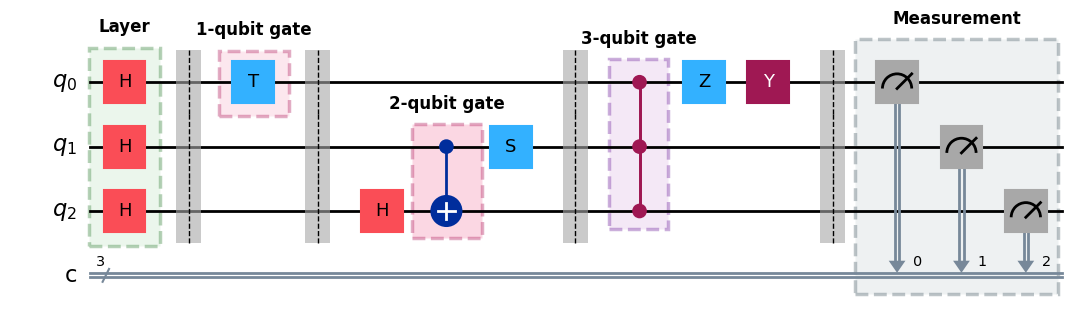

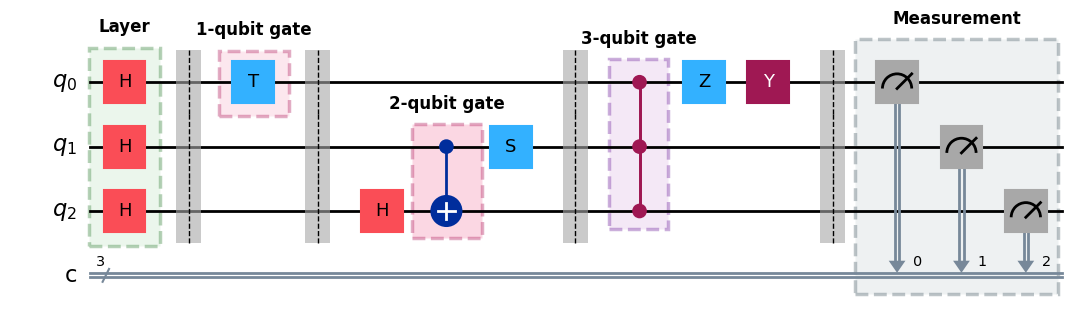

In [199]:
# Cell 3: Visualize with Qiskit + overlay the colored dashed grouping boxes

import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.patches import Rectangle
from qiskit.converters import circuit_to_dag

# Force inline backend in notebooks (helps when VS Code backend state changes)
get_ipython().run_line_magic('matplotlib', 'inline')

# Draw the circuit
fig = qc.draw(output='mpl', fold=-1)
ax = fig.axes[0]
fig.canvas.draw()  # ensure layout is computed

# Compute approximate x-ranges for boxes from the circuit DAG layers.
# The Matplotlib drawer lays layers left-to-right, so we map layer index -> axes fraction.
dag = circuit_to_dag(qc)
layers = list(dag.layers())

def _layer_ops(layer_dict):
    # Qiskit returns a dict with a 'graph' DAGCircuit for each layer
    graph = layer_dict.get('graph')
    # op_nodes() yields DAGOpNode objects
    return list(graph.op_nodes()) if graph is not None else []

def find_layer_index(predicate):
    for i, layer in enumerate(layers):
        for node in _layer_ops(layer):
            if predicate(node):
                return i
    raise RuntimeError('Could not find requested operation in DAG layers')

n_layers = max(1, len(layers))

# 1) 'layer' box: the first layer that contains BOTH H gates on q0 and q2
def _is_h_on(node, q_index: int) -> bool:
    return node.name == 'h' and any(q._index == q_index for q in node.qargs)

layer_idx = None
for i, layer in enumerate(layers):
    ops = _layer_ops(layer)
    if any(_is_h_on(n, 0) for n in ops) and any(_is_h_on(n, 2) for n in ops):
        layer_idx = i
        break
if layer_idx is None:
    layer_idx = find_layer_index(lambda n: n.name == 'h')

# 2) first T gate
t_idx = find_layer_index(lambda n: n.name == 't')

# 3) 3rd CNOT: cx(1,2)
cx12_idx = find_layer_index(
    lambda n: n.name == 'cx' and len(n.qargs) == 2 and n.qargs[0]._index == 1 and n.qargs[1]._index == 2
)

# 4) CCZ
ccz_idx = find_layer_index(lambda n: n.name == 'ccz')

# 5) Measurement
meas_idx = find_layer_index(lambda n: n.name == 'measure')

def layer_to_axes_x(layer_index: int, pad_layers: float = 0.45):
    # Map [0..n_layers) -> [0..1] in axes coordinates
    x0 = (layer_index - pad_layers) / n_layers
    x1 = (layer_index + 1 + pad_layers) / n_layers
    x0 = max(0.01, min(0.99, x0))
    x1 = max(0.01, min(0.99, x1))
    if x1 < x0:
        x0, x1 = x1, x0
    return x0, x1

# ---------- Parameters you can tune (one set per box) ----------
# All values are in axes coordinates [0..1]
# dx, dy shift the box position; dw, dh change width/height
BOX_PARAMS = {
    'layer': {
        'dx': 0.065, 'dy': .12, 'dw': -0.035, 'dh': -0.1, 'edge': '#2e7d32', 'face': '#c8e6c9', 'label': 'Layer'
    },
    'one_qubit': {
        'dx': 0.078, 'dy': .58, 'dw': -0.08, 'dh': -0.57,'edge': '#ad1457', 'face': '#f8bbd0', 'label': '1-qubit gate'
    },
    'two_qubit': {
        'dx': 0.03, 'dy': 0.15, 'dw': -0.08, 'dh': -0.4,'edge': '#ad1457', 'face': '#f48fb1', 'label': '2-qubit gate'
    },
    'three_qubit': {
        'dx': -0.015, 'dy': 0.18, 'dw': -0.09, 'dh': -0.2,'edge': '#6a1b9a', 'face': '#e1bee7', 'label': '3-qubit gate'
    },
    'measurement': {
        'dx': -0.09, 'dy': -0.05, 'dw': 0.09, 'dh': 0.10, 'edge': '#455a64', 'face': '#cfd8dc', 'label': 'Measurement'
    },
}

# Base y and height shared by all boxes before per-box adjustments
y0, h0 = 0.12, 0.80
x0, x1 = layer_to_axes_x(layer_idx)
x2, x3 = layer_to_axes_x(t_idx)
x4, x5 = layer_to_axes_x(cx12_idx)
x6, x7 = layer_to_axes_x(ccz_idx)
x8, x9 = layer_to_axes_x(meas_idx)

def _build_box(name, x_left, x_right):
    p = BOX_PARAMS[name]
    base_w = x_right - x_left
    x = x_left + p['dx']
    y = y0 + p['dy']
    w = max(0.01, base_w + p['dw'])
    h = max(0.05, h0 + p['dh'])
    return dict(label=p['label'], xywh=(x, y, w, h), edge=p['edge'], face=p['face'])

boxes = [
    _build_box('layer', x0, x1),
    _build_box('one_qubit', x2, x3),
    _build_box('two_qubit', x4, x5),
    _build_box('three_qubit', x6, x7),
    _build_box('measurement', x8, x9),
]

for b in boxes:
    x, y, w, h = b['xywh']
    rect = Rectangle(
        (x, y), w, h,
        transform=ax.transAxes,
        fill=True, facecolor=b['face'], alpha=0.35,
        edgecolor=b['edge'], linewidth=2.5, linestyle='--',
        zorder=0
    )
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h + 0.04, b['label'],transform=ax.transAxes, ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
# Display figure explicitly for notebook frontends that ignore implicit show
display(fig)

In [5]:
# Cell 4 (optional): Save the figure to disk

OUT_FIG = 'qiskit_circuit_with_boxes.png'
fig.savefig(OUT_FIG, dpi=200, bbox_inches='tight')
print('Saved:', OUT_FIG)

Saved: qiskit_circuit_with_boxes.png
